# PneuNet on PneumoniaMNIST
Binary classification (Normal vs Pneumonia) using PneuNet (ResNet-18 + Transformer encoder)  
Dataset: **PneumoniaMNIST** from MedMNIST v2

In [1]:
# ── Install all dependencies ──────────────────────────────────────────────────
!pip install medmnist torch torchvision torchinfo scikit-learn matplotlib seaborn pandas numpy tqdm pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.0 MB/s eta 0:00:00


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import math
import time
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
from torchinfo import summary
from datetime import timedelta
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)

import medmnist
from medmnist import PneumoniaMNIST, INFO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1 · Dataset — PneumoniaMNIST

In [3]:
# Dataset info
info = INFO['pneumoniamnist']
print('Task      :', info['task'])
print('Label     :', info['label'])
print('n_channels:', info['n_channels'])
print('n_classes :', len(info['label']))
CLASS_NAMES = list(info['label'].values())
NUM_CLASSES  = len(CLASS_NAMES)
print('Classes   :', CLASS_NAMES)

Task      : binary-class
Label     : {'0': 'normal', '1': 'pneumonia'}
n_channels: 1
n_classes : 2
Classes   : ['normal', 'pneumonia']


In [4]:
# ── Transforms ────────────────────────────────────────────────────────────────
# PneumoniaMNIST images are 28×28 grayscale → resize to 224×224 and convert to 3-ch
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # replicate to 3 channels
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ── Load splits ───────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
DATA_DIR     = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)   # create dir before MedMNIST tries to use it

train_dataset = PneumoniaMNIST(split='train', transform=train_transform,    download=True, root=DATA_DIR)
val_dataset   = PneumoniaMNIST(split='val',   transform=val_test_transform,  download=True, root=DATA_DIR)
test_dataset  = PneumoniaMNIST(split='test',  transform=val_test_transform,  download=True, root=DATA_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_dataset):>5} samples  |  {len(train_loader):>4} batches')
print(f'Val   : {len(val_dataset):>5} samples  |  {len(val_loader):>4} batches')
print(f'Test  : {len(test_dataset):>5} samples  |  {len(test_loader):>4} batches')

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.72MB/s]

Train :  4708 samples  |   295 batches
Val   :   524 samples  |    33 batches
Test  :   624 samples  |    39 batches


           Train  Val  Test
normal      1214  135   234
pneumonia   3494  389   390


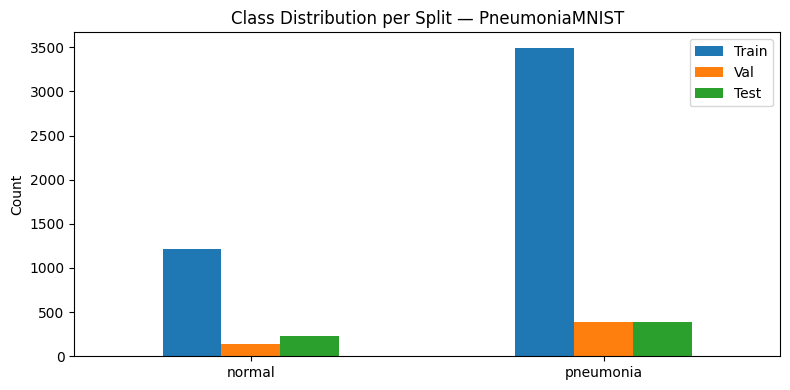

In [5]:
# ── Class distribution ────────────────────────────────────────────────────────
def label_counts(dataset, name):
    labels = np.array(dataset.labels).flatten()
    unique, counts = np.unique(labels, return_counts=True)
    return pd.Series(counts, index=[CLASS_NAMES[i] for i in unique], name=name)

dist_df = pd.concat([label_counts(train_dataset, 'Train'),
                     label_counts(val_dataset,   'Val'),
                     label_counts(test_dataset,  'Test')], axis=1)
print(dist_df)

dist_df.plot(kind='bar', figsize=(8, 4), rot=0)
plt.title('Class Distribution per Split — PneumoniaMNIST')
plt.ylabel('Count'); plt.tight_layout(); plt.show()

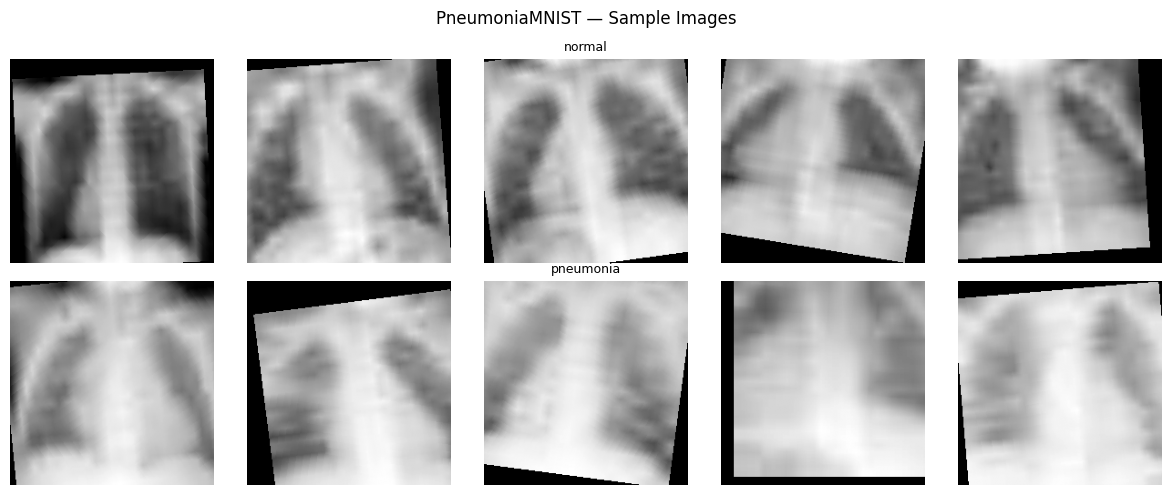

In [6]:
# ── Sample images ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idxs = np.where(np.array(train_dataset.labels).flatten() == cls_idx)[0][:5]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        ax = axes[cls_idx, j]
        ax.imshow(img[0].numpy(), cmap='gray')
        ax.set_title(cls_name if j == 2 else '', fontsize=9)
        ax.axis('off')
plt.suptitle('PneumoniaMNIST — Sample Images', fontsize=12)
plt.tight_layout(); plt.show()

## 2 · Model — PneuNet (ResNet-18 + Transformer)

In [7]:
class PneuNet(nn.Module):
    """
    PneuNet: ResNet-18 backbone + Transformer Encoder + MLP head.

    Parameters
    ----------
    num_classes     : int   – number of output classes
    freeze_backbone : bool  – freeze ResNet weights
    input_channels  : int   – 1 (grayscale) or 3 (RGB/replicated)
    use_80_tokens   : bool  – AdaptiveAvgPool2d(10×8)=80 tokens; else 7×7=49
    """
    def __init__(self, num_classes=2, freeze_backbone=False,
                 input_channels=3, use_80_tokens=True):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if input_channels != 3:
            resnet.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7,
                                     stride=2, padding=3, bias=False)

        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4,
        )  # → [B, 512, 7, 7]

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.post_resnet_bn = nn.BatchNorm2d(512)

        if use_80_tokens:
            self.adaptive_pool = nn.AdaptiveAvgPool2d((10, 8))  # 80 tokens
            token_count = 80
        else:
            self.adaptive_pool = nn.Identity()                  # 49 tokens
            token_count = 49

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512, nhead=8, dim_feedforward=2048,
            dropout=0.1, activation='relu', batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=6)
        self.layer_norm = nn.LayerNorm(512)

        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(token_count * 512, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(16, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)          # [B, 512, 7, 7]
        x = self.post_resnet_bn(x)    # [B, 512, 7, 7]
        x = self.adaptive_pool(x)     # [B, 512, H, W]
        b, c, h, w = x.shape
        x = x.view(b, c, h * w).permute(0, 2, 1)   # [B, tokens, 512]
        x = self.transformer_encoder(x)             # [B, tokens, 512]
        x = self.layer_norm(x)                      # [B, tokens, 512]
        x = x.view(b, -1)                           # [B, tokens*512]
        return self.mlp(x)                          # [B, num_classes]


model = PneuNet(num_classes=NUM_CLASSES, freeze_backbone=True,
                input_channels=3, use_80_tokens=True)
model.to(device)
summary(model, (1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.0MB/s]


Layer (type:depth-idx)                        Output Shape              Param #
PneuNet                                       [1, 2]                    --
├─Sequential: 1-1                             [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           (73,984)
│    │    └─BasicBlock: 3-2                   [1, 64, 56, 56]           (73,984)
│    └─Sequential: 2-6                        [1, 128, 28, 28]          --
│    │    └─BasicBlock: 3-3                   [1, 128, 28, 28]          (230,144)
│    │    └─BasicBlock: 3-4                   [1, 128, 28, 28]      

## 3 · Metrics Helper

In [8]:
def custom_metrics(y_pred_tensor, y_true_tensor, loss):
    """
    Compute classification metrics.
    y_pred_tensor : raw logits  [N, C]
    y_true_tensor : int labels  [N]
    """
    y_pred_classes = torch.argmax(y_pred_tensor, dim=1)
    y_true = y_true_tensor.cpu().numpy().astype(int)
    y_pred = y_pred_classes.cpu().numpy().astype(int)

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mcc       = matthews_corrcoef(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    tn = cm[0, 0]; fp = cm[0, 1:].sum()
    fn = cm[1:, 0].sum(); tp = cm[1:, 1:].sum()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # Per-class AUC → macro average
    probs = torch.softmax(y_pred_tensor, dim=1).cpu().numpy()
    auc_scores = []
    for cls_idx in range(probs.shape[1]):
        bin_true = (y_true == cls_idx).astype(float)
        if bin_true.sum() > 0 and (1 - bin_true).sum() > 0:
            auc_scores.append(roc_auc_score(bin_true, probs[:, cls_idx]))
    auc_avg = float(np.mean(auc_scores)) if auc_scores else float('nan')

    return {
        'loss': loss, 'accuracy': accuracy,
        'precision': precision, 'recall': recall,
        'f1_score': f1, 'specificity': specificity,
        'sensitivity': sensitivity, 'mcc': mcc, 'auc': auc_avg,
    }

## 4 · Training

In [9]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)

NUM_EPOCHS = 25

metric_names = ['loss', 'accuracy', 'precision', 'recall',
                'f1_score', 'specificity', 'sensitivity', 'mcc', 'auc']
train_history = {m: [] for m in metric_names}
val_history   = {m: [] for m in metric_names}

# ── Timing accumulators ───────────────────────────────────────────────────────
total_train_time = 0.0
total_val_time   = 0.0
epoch_train_times = []
epoch_val_times   = []

overall_start = time.time()

for epoch in range(NUM_EPOCHS):
    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    total_loss, all_preds, all_targets = 0.0, [], []

    t_train_start = time.time()
    for data, targets in tqdm(train_loader,
                              desc=f'Train Epoch [{epoch+1:02d}/{NUM_EPOCHS}]',
                              leave=False):
        data    = data.to(device)
        targets = targets.squeeze(1).long().to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(outputs.detach().cpu())
        all_targets.append(targets.detach().cpu())

    epoch_train_sec = time.time() - t_train_start
    total_train_time   += epoch_train_sec
    epoch_train_times.append(epoch_train_sec)

    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    avg_loss    = total_loss / len(train_loader)
    tr_metrics  = custom_metrics(all_preds, all_targets, avg_loss)
    for m in metric_names:
        train_history[m].append(tr_metrics[m])

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    t_val_start = time.time()
    with torch.no_grad():
        for data, targets in tqdm(val_loader,
                                  desc=f'  Val  Epoch [{epoch+1:02d}/{NUM_EPOCHS}]',
                                  leave=False):
            data    = data.to(device)
            targets = targets.squeeze(1).long().to(device)
            outputs = model(data)
            loss    = criterion(outputs, targets)
            total_loss += loss.item()
            all_preds.append(outputs.cpu())
            all_targets.append(targets.cpu())

    epoch_val_sec = time.time() - t_val_start
    total_val_time  += epoch_val_sec
    epoch_val_times.append(epoch_val_sec)

    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    avg_loss    = total_loss / len(val_loader)
    vl_metrics  = custom_metrics(all_preds, all_targets, avg_loss)
    for m in metric_names:
        val_history[m].append(vl_metrics[m])

    scheduler.step()

    # ── Per-epoch summary ─────────────────────────────────────────────────────
    print(
        f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
        f'Train loss: {tr_metrics["loss"]:.4f}  acc: {tr_metrics["accuracy"]:.4f}  '
        f'Val loss: {vl_metrics["loss"]:.4f}  acc: {vl_metrics["accuracy"]:.4f}  '
        f'| Train {epoch_train_sec:.1f}s  Val {epoch_val_sec:.1f}s  '
        f'Total epoch {epoch_train_sec + epoch_val_sec:.1f}s'
    )

overall_elapsed = time.time() - overall_start

# ── Timing summary ────────────────────────────────────────────────────────────
avg_train_per_epoch = total_train_time / NUM_EPOCHS
avg_val_per_epoch   = total_val_time   / NUM_EPOCHS

print()
print('=' * 65)
print('TIMING SUMMARY')
print('=' * 65)
print(f'  Total training time       : {str(timedelta(seconds=int(total_train_time)))}')
print(f'  Total validation time     : {str(timedelta(seconds=int(total_val_time)))}')
print(f'  Total wall-clock time     : {str(timedelta(seconds=int(overall_elapsed)))}')
print(f'  Avg train time / epoch    : {avg_train_per_epoch:.2f} s')
print(f'  Avg val   time / epoch    : {avg_val_per_epoch:.2f} s')
print(f'  Min train time (epoch)    : {min(epoch_train_times):.2f} s  (epoch {np.argmin(epoch_train_times)+1})')
print(f'  Max train time (epoch)    : {max(epoch_train_times):.2f} s  (epoch {np.argmax(epoch_train_times)+1})')
print('=' * 65)

Epoch [01/25]  Train loss: 0.5221  acc: 0.7441  Val loss: 0.4019  acc: 0.7557  | Train 31.2s  Val 1.3s  Total epoch 32.5s


Epoch [02/25]  Train loss: 0.4534  acc: 0.7810  Val loss: 0.3502  acc: 0.8359  | Train 26.7s  Val 1.7s  Total epoch 28.4s


Epoch [03/25]  Train loss: 0.3842  acc: 0.8260  Val loss: 0.3975  acc: 0.7844  | Train 27.5s  Val 1.3s  Total epoch 28.9s


Epoch [04/25]  Train loss: 0.3631  acc: 0.8335  Val loss: 0.2889  acc: 0.9141  | Train 28.4s  Val 1.3s  Total epoch 29.7s


Epoch [05/25]  Train loss: 0.3413  acc: 0.8526  Val loss: 0.3870  acc: 0.8855  | Train 29.7s  Val 1.5s  Total epoch 31.1s


...

Epoch [21/25]  Train loss: 0.2484  acc: 0.9114  Val loss: 0.2305  acc: 0.9008  | Train 28.6s  Val 1.3s  Total epoch 29.9s


Epoch [22/25]  Train loss: 0.2332  acc: 0.9095  Val loss: 0.2048  acc: 0.9122  | Train 28.6s  Val 1.4s  Total epoch 29.9s


Epoch [23/25]  Train loss: 0.2194  acc: 0.9138  Val loss: 0.2213  acc: 0.9179  | Train 28.7s  Val 1.3s  Total epoch 30.0s


Epoch [24/25]  Train loss: 0.2346  acc: 0.9121  Val loss: 0.1712  acc: 0.9389  | Train 28.5s  Val 1.3s  Total epoch 29.8s


Epoch [25/25]  Train loss: 0.2376  acc: 0.9129  Val loss: 0.2533  acc: 0.8931  | Train 28.5s  Val 1.8s  Total epoch 30.3s

TIMING SUMMARY
  Total training time       : 0:11:55
  Total validation time     : 0:00:35
  Total wall-clock time     : 0:12:31
  Avg train time / epoch    : 28.63 s
  Avg val   time / epoch    : 1.42 s
  Min train time (epoch)    : 26.72 s  (epoch 2)
  Max train time (epoch)    : 31.20 s  (epoch 1)


## 5 · Per-epoch Timing Plot

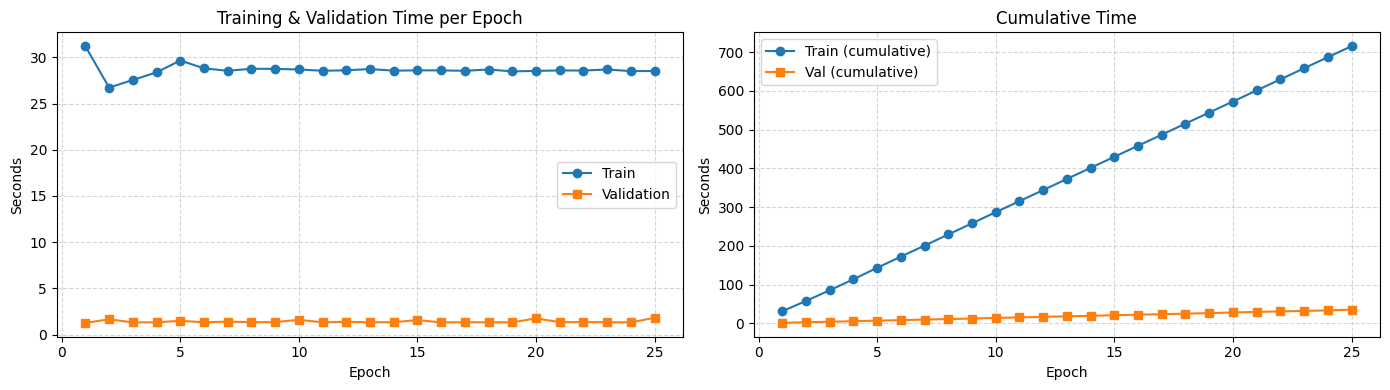

In [10]:
epochs_rng = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_rng, epoch_train_times, marker='o', label='Train')
axes[0].plot(epochs_rng, epoch_val_times,   marker='s', label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Seconds')
axes[0].set_title('Training & Validation Time per Epoch')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

cum_train = np.cumsum(epoch_train_times)
cum_val   = np.cumsum(epoch_val_times)
axes[1].plot(epochs_rng, cum_train, marker='o', label='Train (cumulative)')
axes[1].plot(epochs_rng, cum_val,   marker='s', label='Val (cumulative)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Seconds')
axes[1].set_title('Cumulative Time')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()

## 6 · Metric Curves

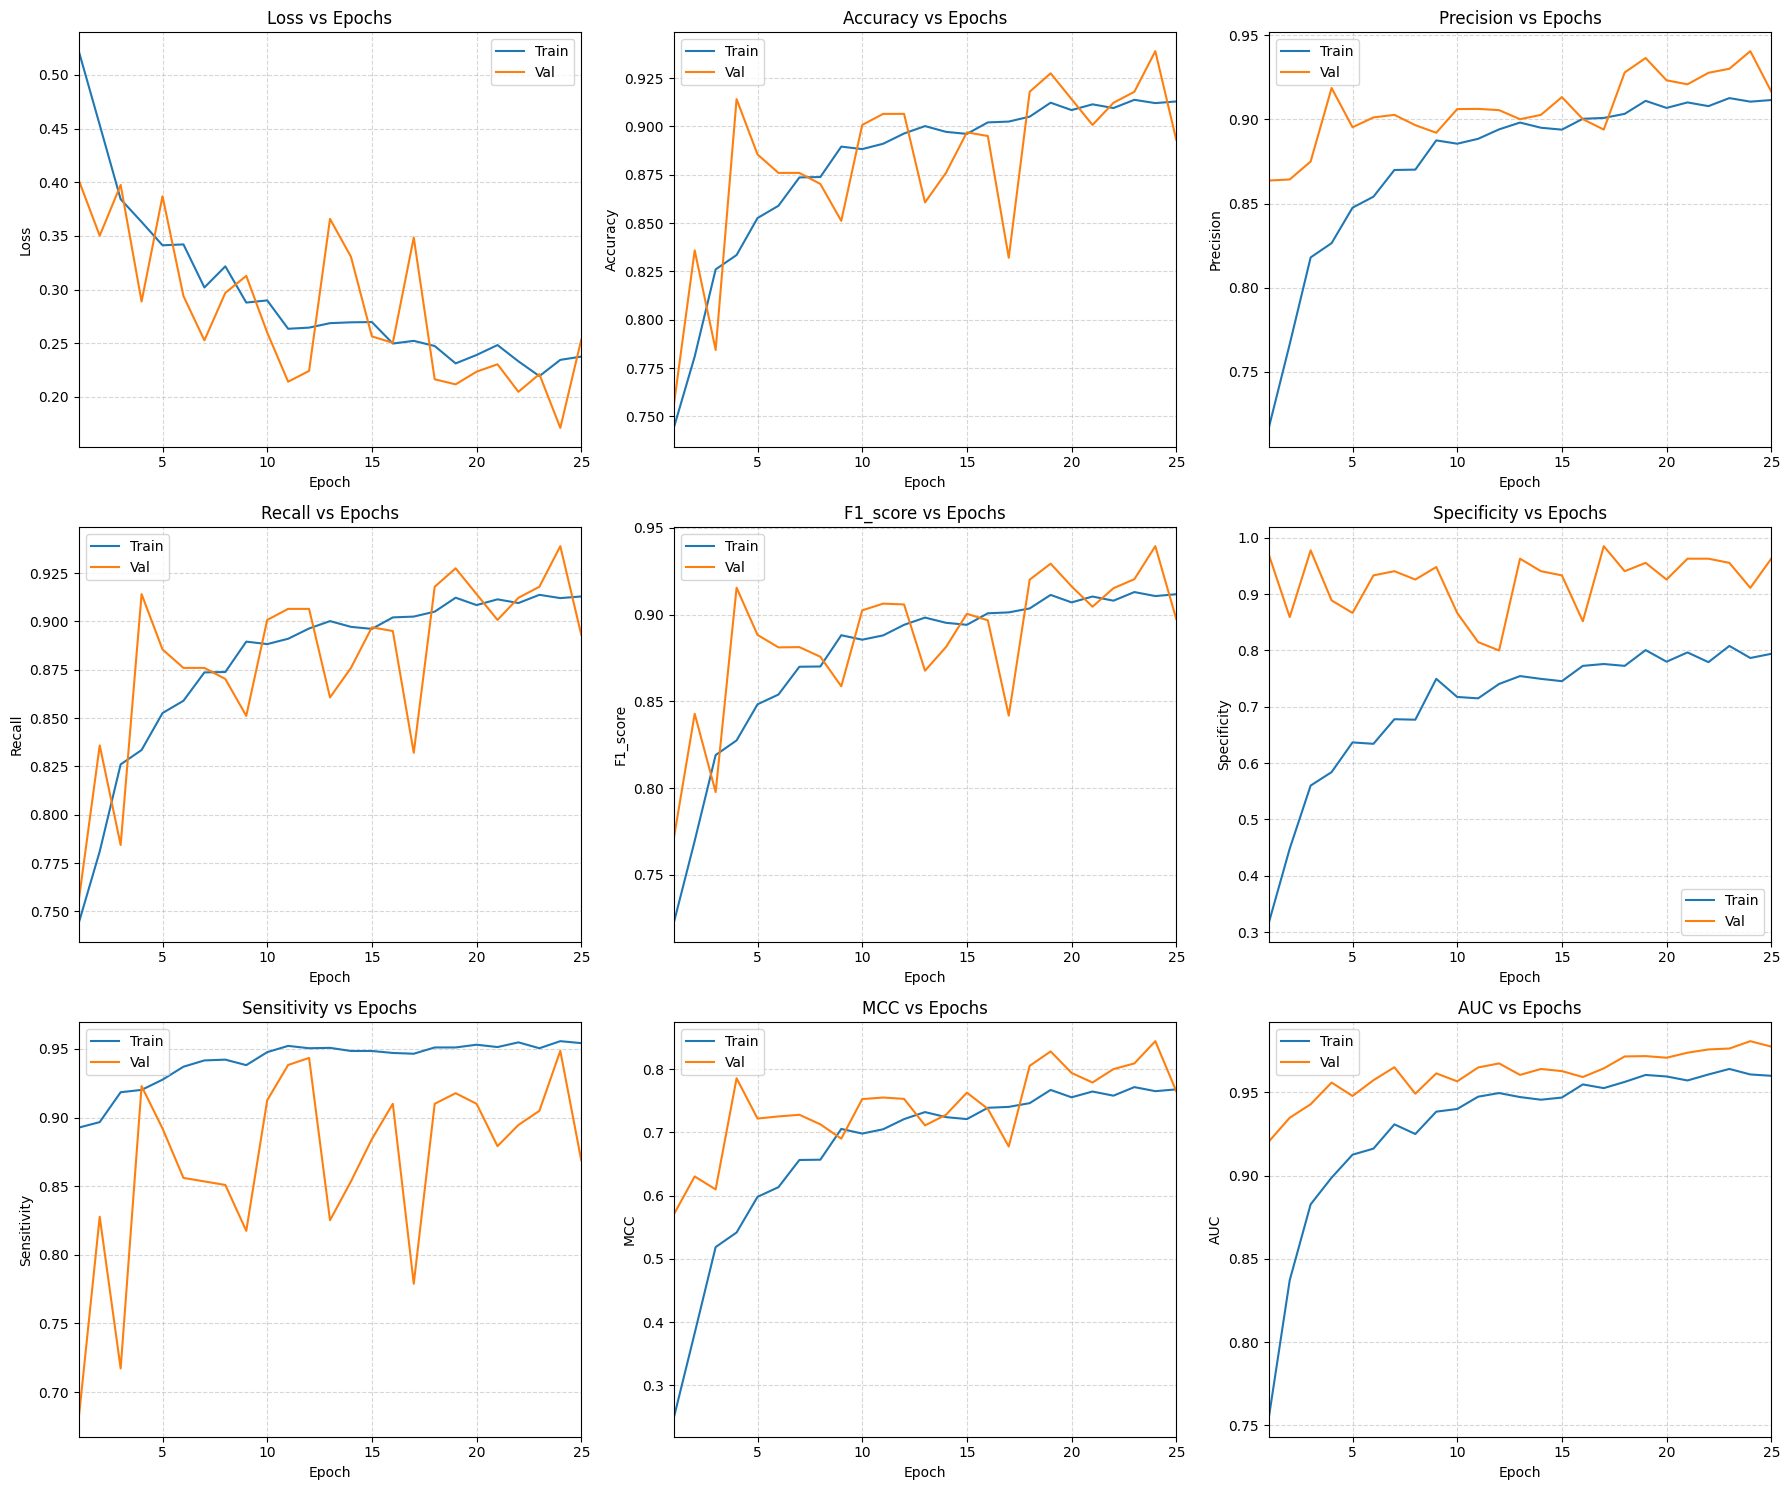

In [11]:
def plot_metrics(train_hist, val_hist, metric_names):
    n = len(metric_names)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()
    rng  = range(1, NUM_EPOCHS + 1)
    for ax, name in zip(axes, metric_names):
        ax.plot(rng, train_hist[name], label='Train')
        ax.plot(rng, val_hist[name],   label='Val')
        ax.set_xlabel('Epoch')
        label = name.upper() if name in ('auc', 'mcc') else name.capitalize()
        ax.set_ylabel(label); ax.set_title(f'{label} vs Epochs')
        ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlim(1, NUM_EPOCHS)
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

plot_metrics(train_history, val_history, metric_names)

## 7 · Test Evaluation

In [12]:
model.eval()
total_loss, all_preds, all_targets = 0.0, [], []

t_test_start = time.time()
with torch.no_grad():
    for data, targets in tqdm(test_loader, desc='Testing'):
        data    = data.to(device)
        targets = targets.squeeze(1).long().to(device)
        outputs = model(data)
        loss    = criterion(outputs, targets)
        total_loss += loss.item()
        all_preds.append(outputs.cpu())
        all_targets.append(targets.cpu())

test_time = time.time() - t_test_start
all_preds   = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

avg_loss    = total_loss / len(test_loader)
test_metrics = custom_metrics(all_preds, all_targets, avg_loss)

print(f'Test inference time: {test_time:.2f} s  ({test_time/len(test_dataset)*1000:.2f} ms/sample)')
print()
print('TEST METRICS')
print('-' * 50)
for k, v in test_metrics.items():
    print(f'  {k:>12} : {v:.4f}')

Testing: 100%|██████████| 39/39 [00:01<00:00, 23.88it/s]

Test inference time: 1.64 s  (2.62 ms/sample)

TEST METRICS
--------------------------------------------------
          loss : 0.3278
      accuracy : 0.8766
     precision : 0.8767
        recall : 0.8766
      f1_score : 0.8767
   specificity : 0.8376
   sensitivity : 0.9000
           mcc : 0.7370
           auc : 0.9340


In [13]:
# ── Classification report ─────────────────────────────────────────────────────
true_labels = all_targets.numpy().astype(int)
pred_labels = torch.argmax(all_preds, dim=1).numpy().astype(int)

print(classification_report(true_labels, pred_labels,
                             target_names=CLASS_NAMES, digits=4))
n_errors = np.sum(true_labels != pred_labels)
print(f'{n_errors} errors in {len(pred_labels)} test samples  '
      f'→ accuracy {accuracy_score(true_labels, pred_labels)*100:.2f}%')

              precision    recall  f1-score   support

      normal     0.8340    0.8376    0.8358       234
   pneumonia     0.9023    0.9000    0.9012       390

    accuracy                         0.8766       624
   macro avg     0.8682    0.8688    0.8685       624
weighted avg     0.8767    0.8766    0.8767       624

77 errors in 624 test samples  → accuracy 87.66%


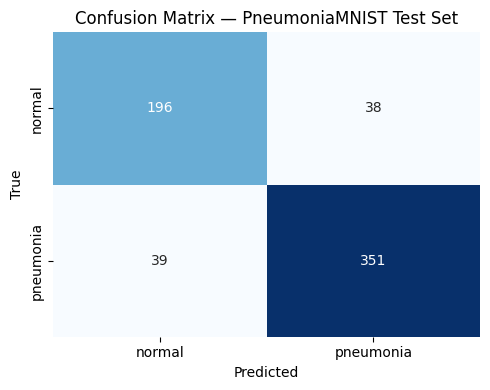

In [14]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — PneumoniaMNIST Test Set')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

## 8 · Full Timing Table (per epoch)

In [15]:
timing_df = pd.DataFrame({
    'Epoch'          : list(epochs_rng),
    'Train (s)'      : [round(t, 2) for t in epoch_train_times],
    'Val (s)'        : [round(t, 2) for t in epoch_val_times],
    'Total (s)'      : [round(tr + vl, 2) for tr, vl in zip(epoch_train_times, epoch_val_times)],
    'Train Acc'      : [round(v, 4) for v in train_history['accuracy']],
    'Val Acc'        : [round(v, 4) for v in val_history['accuracy']],
    'Train Loss'     : [round(v, 4) for v in train_history['loss']],
    'Val Loss'       : [round(v, 4) for v in val_history['loss']],
})
display(timing_df)

# Summary row
print()
summary_row = pd.DataFrame([{
    'Epoch': 'TOTAL/AVG',
    'Train (s)': round(total_train_time, 2),
    'Val (s)'  : round(total_val_time, 2),
    'Total (s)': round(total_train_time + total_val_time, 2),
    'Train Acc': round(np.mean(train_history['accuracy']), 4),
    'Val Acc'  : round(np.mean(val_history['accuracy']), 4),
    'Train Loss': round(np.mean(train_history['loss']), 4),
    'Val Loss'  : round(np.mean(val_history['loss']), 4),
}])
display(summary_row)

,Epoch,Train (s),Val (s),Total (s),Train Acc,Val Acc,Train Loss,Val Loss
0,1,31.20,1.27,32.48,0.7441,0.7557,0.5221,0.4019
1,2,26.72,1.66,28.39,0.7810,0.8359,0.4534,0.3502
2,3,27.55,1.32,28.87,0.8260,0.7844,0.3842,0.3975
3,4,28.37,1.33,29.70,0.8335,0.9141,0.3631,0.2889
4,5,29.65,1.49,31.15,0.8526,0.8855,0.3413,0.3870
5,6,28.81,1.33,30.14,0.8590,0.8760,0.3421,0.2940
6,7,28.54,1.41,29.95,0.8736,0.8760,0.3020,0.2528
7,8,28.76,1.34,30.10,0.8738,0.8702,0.3217,0.2970
8,9,28.75,1.36,30.10,0.8895,0.8511,0.2879,0.3128
9,10,28.68,1.60,30.29,0.8883,0.9008,0.2900,0.2600


,Epoch,Train (s),Val (s),Total (s),Train Acc,Val Acc,Train Loss,Val Loss
0,TOTAL/AVG,715.71,35.4,751.11,0.8797,0.8818,0.2935,0.2786
